<a href="https://colab.research.google.com/github/AliEbaa/My-Data-Science-Projects/blob/main/Data_project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing The Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


#Dataset Description


In [ ]:
# Connect the original dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# The Original columnes names
col_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

# Download Data
df = pd.read_csv(url, names=col_names)

# The first 10 columnes projection
print("Preview of the raw data:")
df.head(10)


Preview of the raw data:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


#Cleaning Data

In [ ]:
# Show the types of the Data
print("Data types before cleaning:")
print(df.dtypes)
print("\n")

# Cheak the unique values in each columnes
print("Unique values per column:")
for col in df.columns:
    print(col, ":", df[col].unique()[:10])  # Project the first 10 unique values

print("\n")

# Replace the Nan values by ?
df = df.replace("?", np.nan)

# Cheak the happening of the changes
print("Checking missing values after replacing '?':")
print(df.isna().sum())


Data types before cleaning:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca           object
thal         object
target        int64
dtype: object


Unique values per column:
age : [63. 67. 37. 41. 56. 62. 57. 53. 44. 52.]
sex : [1. 0.]
cp : [1. 4. 3. 2.]
trestbps : [145. 160. 120. 130. 140. 172. 150. 110. 132. 117.]
chol : [233. 286. 229. 250. 204. 236. 268. 354. 254. 203.]
fbs : [1. 0.]
restecg : [2. 0. 1.]
thalach : [150. 108. 129. 187. 172. 178. 160. 163. 147. 155.]
exang : [0. 1.]
oldpeak : [2.3 1.5 2.6 3.5 1.4 0.8 3.6 0.6 3.1 0.4]
slope : [3. 2. 1.]
ca : ['0.0' '3.0' '2.0' '1.0' '?']
thal : ['6.0' '3.0' '7.0' '?']
target : [0 2 1 3 4]


Checking missing values after replacing '?':
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
old

#Dealing with the Missing Data

In [ ]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')


print("Data types after conversion:")
print(df.dtypes)
print("\n")

# Show the number of missing values per columne
print("Missing values per column:")
print(df.isna().sum())
print("\n")

# Handle the missing values in "ca" and "thal" columnes
# Replace the missing values by the median value of each columne

df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].median())

# The final cheak
print("Missing values after cleaning:")
print(df.isna().sum())


Data types after conversion:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object


Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


Missing values after cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


#Descriptive Analysis and Basic Statistics

In [ ]:


# Show General Information about data
print("General Info:")
print(df.info())
print("\n")

# Basic Statistics for all degital columnes
print("Descriptive Statistics:")
print(df.describe())
print("\n")

# The number of unic values for all columnes
print("Unique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")
print("\n")

# The target distibution (number of sick and unsick values)
print("Target distribution:")
print(df['target'].value_counts())
print("\n")

# The Persentage of each catigory
print("Target distribution (normalized):")
print(df['target'].value_counts(normalize=True))


General Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None


Descriptive Statistics:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.4

#Visual Analysis

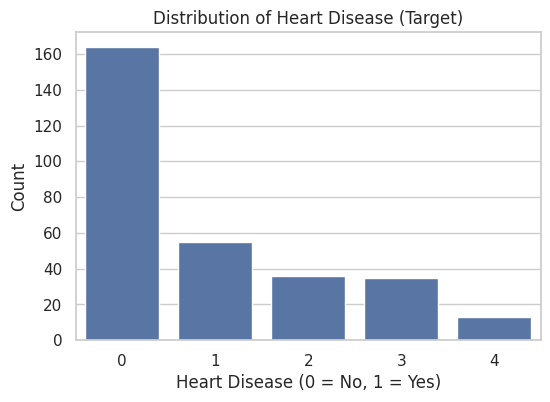

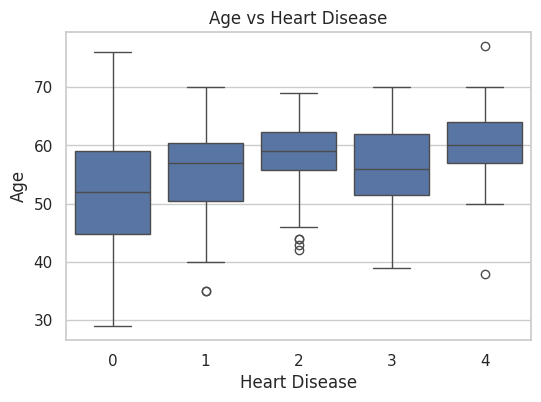

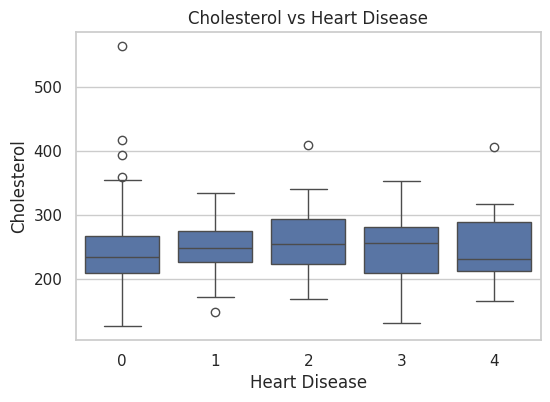

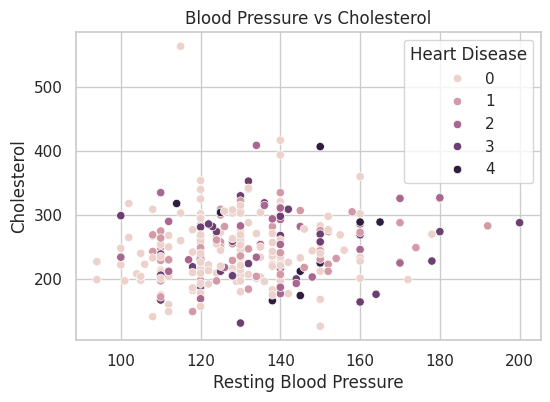

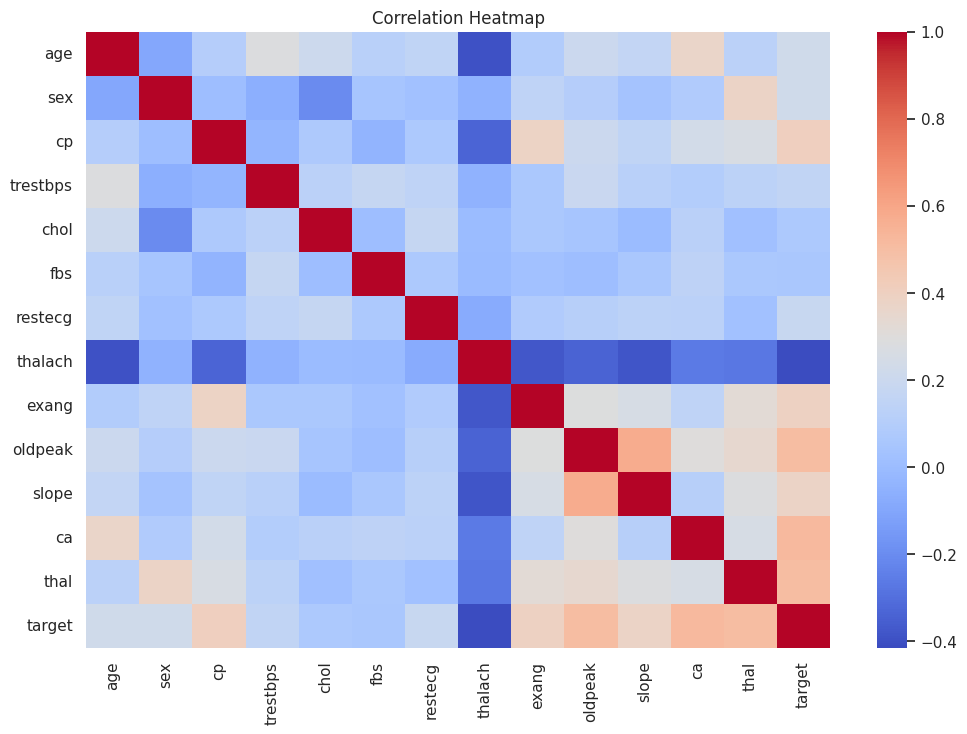

In [ ]:
# General visualizing settings
plt.figure(figsize=(6, 4))
sns.set(style="whitegrid")

sns.countplot(x='target', data=df)
plt.title("Distribution of Heart Disease (Target)")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


plt.figure(figsize=(6, 4))
sns.boxplot(x='target', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.show()


plt.figure(figsize=(6, 4))
sns.boxplot(x='target', y='chol', data=df)
plt.title("Cholesterol vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Cholesterol")
plt.show()


plt.figure(figsize=(6, 4))
sns.scatterplot(x='trestbps', y='chol', hue='target', data=df)
plt.title("Blood Pressure vs Cholesterol")
plt.xlabel("Resting Blood Pressure")
plt.ylabel("Cholesterol")
plt.legend(title="Heart Disease")
plt.show()

# Correlation Matrix
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


#Preparing Dataset for Modualation

In [ ]:
# Feature Separation from the Target
X = df.drop('target', axis=1)
y = df['target']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)
print("\n")

# Splitiing data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\n")

# Apply Standard Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")


Shape of features (X): (303, 13)
Shape of target (y): (303,)


Training set size: (242, 13)
Testing set size: (61, 13)


Scaling completed.


#Building the First Model and Evaluate It

Accuracy: 0.6065573770491803


Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.88      0.83        33
           1       0.36      0.36      0.36        11
           2       0.20      0.14      0.17         7
           3       0.43      0.43      0.43         7
           4       0.00      0.00      0.00         3

    accuracy                           0.61        61
   macro avg       0.36      0.36      0.36        61
weighted avg       0.56      0.61      0.58        61



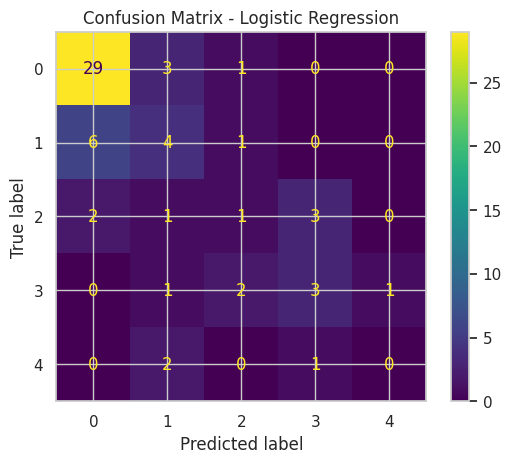

In [ ]:
# Building Model
model = LogisticRegression(max_iter=1000, random_state=42)

# Training Model
model.fit(X_train_scaled, y_train)

# predecting on test data
y_pred = model.predict(X_test_scaled)

# Performance Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


#Interpretation of The Model and Drawing Conclusions.

Feature Importance (Logistic Regression):
     Feature  Coefficient
11        ca    -1.208248
1        sex    -0.627488
2         cp    -0.583499
9    oldpeak    -0.496011
12      thal    -0.456838
10     slope    -0.372461
3   trestbps    -0.350573
8      exang    -0.278892
6    restecg    -0.273227
7    thalach     0.242954
4       chol    -0.160720
5        fbs     0.119007
0        age     0.030755




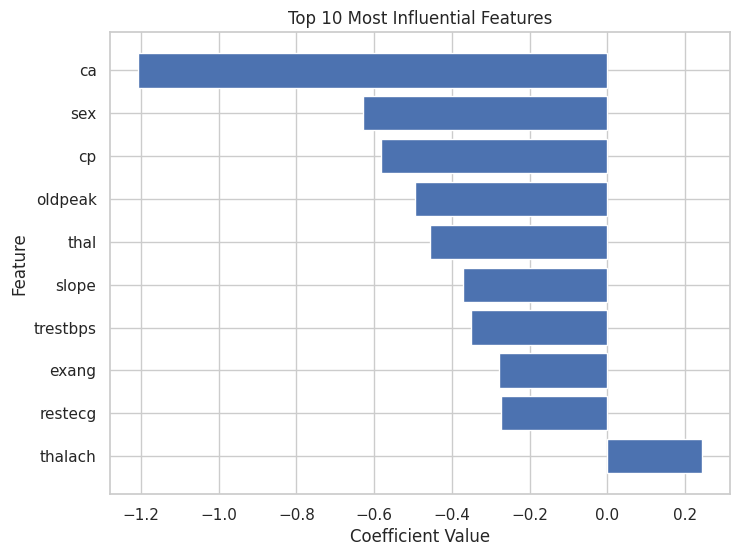

In [ ]:
# Extracting Model Parameters
feature_names = X.columns
coefficients = model.coef_[0]

# Building Dataframe to visualisation
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Ranking Features by Absolute Impact
importance_df['Abs_Coefficient'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values(by='Abs_Coefficient', ascending=False)

print("Feature Importance (Logistic Regression):")
print(importance_df[['Feature', 'Coefficient']])
print("\n")

# Printing the most important Parameters
plt.figure(figsize=(8, 6))
plt.barh(
    importance_df['Feature'][:10][::-1],
    importance_df['Coefficient'][:10][::-1]
)
plt.title("Top 10 Most Influential Features")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()


#Model Optimization Using The Random Forest

Random Forest Accuracy:
0.5409836065573771


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.88        33
           1       0.12      0.09      0.11        11
           2       0.12      0.14      0.13         7
           3       0.10      0.14      0.12         7
           4       0.00      0.00      0.00         3

    accuracy                           0.54        61
   macro avg       0.24      0.26      0.25        61
weighted avg       0.51      0.54      0.53        61



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


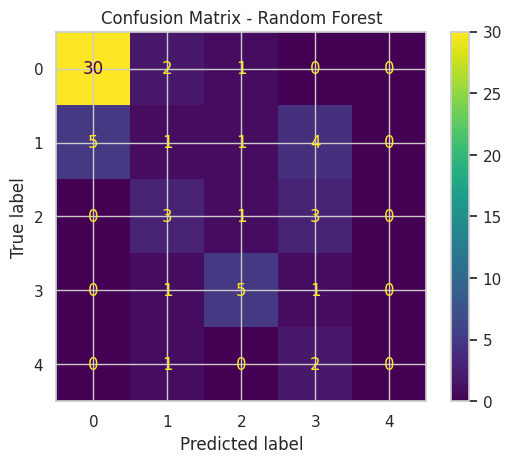

In [ ]:
# Building Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42,
    class_weight='balanced'  # Important in a medical field
)

# Training Model
rf_model.fit(X_train, y_train)

# Prediction
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))
print("\n")

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(confusion_matrix=cm_rf).plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()


#Adjusting the Threshold to Improve Recall

Classification Report with threshold = 0.35
              precision    recall  f1-score   support

           0       0.55      0.94      0.70        33
           1       0.20      0.09      0.12        11
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00         7
           4       0.00      0.00      0.00         3

    accuracy                           0.52        61
   macro avg       0.15      0.21      0.16        61
weighted avg       0.34      0.52      0.40        61



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


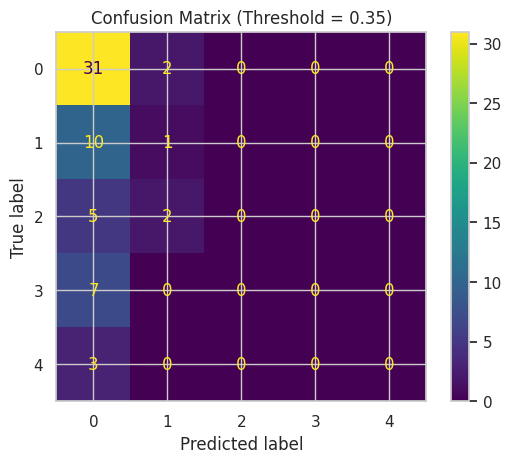

In [ ]:
# Obtaining Infection Probabilities from the Random Forest Model
y_probs = rf_model.predict_proba(X_test)[:, 1]

# Choose the Threshold less than 0.5
threshold = 0.35
y_pred_threshold = (y_probs >= threshold).astype(int)

# The Evaluation after the Threshold Adjustement
print(f"Classification Report with threshold = {threshold}")
print(classification_report(y_test, y_pred_threshold))

# Confusion Matrix
cm_thresh = confusion_matrix(y_test, y_pred_threshold)
ConfusionMatrixDisplay(confusion_matrix=cm_thresh).plot()
plt.title(f"Confusion Matrix (Threshold = {threshold})")
plt.show()


#Feature Importance Comparison

Feature Importance Comparison:
     Feature  RF_Importance  Logistic_Importance
7    thalach       0.136931             0.242954
9    oldpeak       0.127936             0.496011
0        age       0.121042             0.030755
4       chol       0.116830             0.160720
11        ca       0.114306             1.208248
3   trestbps       0.098908             0.350573
12      thal       0.071895             0.456838
2         cp       0.063474             0.583499
10     slope       0.044584             0.372461
8      exang       0.039207             0.278892




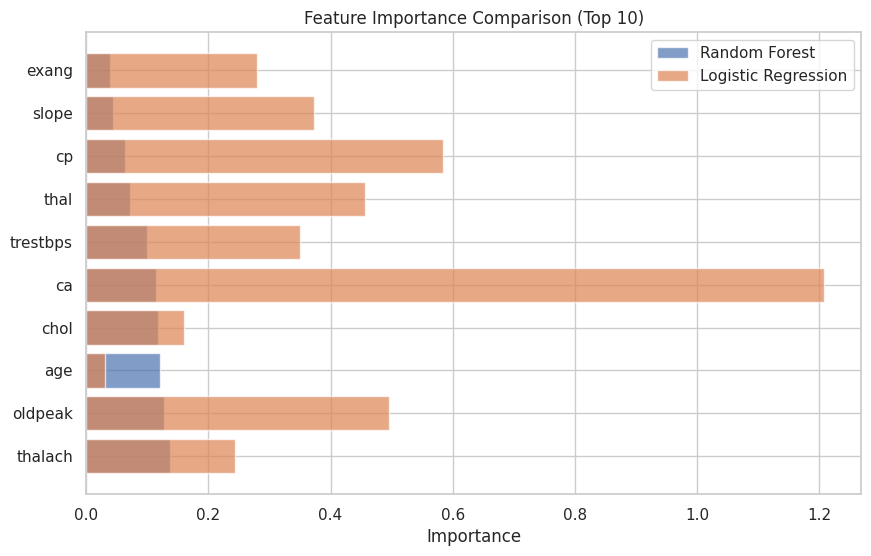

In [ ]:
# Feature Importance from the Random Forest
rf_importance = rf_model.feature_importances_

rf_df = pd.DataFrame({
    'Feature': X.columns,
    'RF_Importance': rf_importance
})

# Feature Importance from Logistic Regression (Abs Coefficient)
log_df = importance_df[['Feature', 'Abs_Coefficient']].copy()
log_df.rename(columns={'Abs_Coefficient': 'Logistic_Importance'}, inplace=True)

# Results Merge
comparison_df = pd.merge(rf_df, log_df, on='Feature')

# Sort by Random Forest
comparison_df = comparison_df.sort_values(
    by='RF_Importance',
    ascending=False
)

print("Feature Importance Comparison:")
print(comparison_df.head(10))
print("\n")

# Comparison Chart for the Top 10 Features
top_features = comparison_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['RF_Importance'], alpha=0.7, label='Random Forest')
plt.barh(top_features['Feature'], top_features['Logistic_Importance'], alpha=0.7, label='Logistic Regression')
plt.xlabel("Importance")
plt.title("Feature Importance Comparison (Top 10)")
plt.legend()
plt.show()


# Hyperparameter Tuning using GridSearchCV

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best Parameters Found:
{'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


Best Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        33
           1       0.33      0.27      0.30        11
           2       0.20      0.29      0.24         7
           3       0.12      0.14      0.13         7
           4       0.00      0.00      0.00         3

    accuracy                           0.57        61
   macro avg       0.31      0.32      0.31        61
weighted avg       0.57      0.57      0.57        61



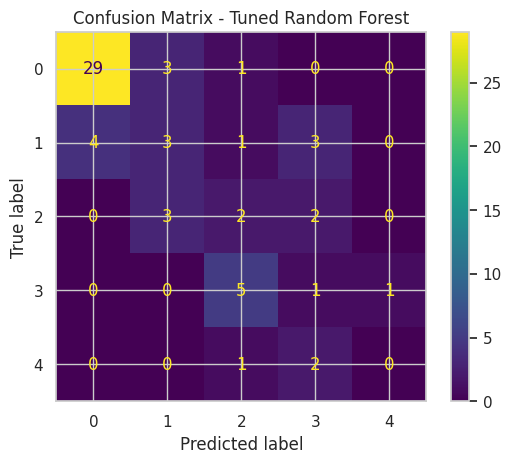

In [ ]:
# Identification of the Main Random Forest Model
rf_base = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

#  Search Space (Limited and Realistic)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Prepare the GridSearch
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='recall',   # Medical Decision
    cv=5,
    n_jobs=-1
)

# Training
grid_search.fit(X_train, y_train)

# Best Model
best_rf = grid_search.best_estimator_

print("Best Parameters Found:")
print(grid_search.best_params_)
print("\n")

# Evaluation on Testing Data
y_pred_best = best_rf.predict(X_test)

print("Best Random Forest Classification Report:")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix
cm_best = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(confusion_matrix=cm_best).plot()
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()
